# Fast analytic TTV grid scanner

This notebook provides a fast analytic tool to scan possible perturbing planets and identify configurations that approximately match an observed TTV amplitude and super-period.

The goal is not to replace N-body TTV modelling. The goal is to quickly identify promising regions in perturber period and mass. These regions can then be followed up with TTVFast, REBOUND, or Exo-Striker photodynamical/N-body modelling.

The analytic model uses the super-period relation

```text
P_sup = 1 / | p/P_pert - q/P_trans |
```

where the period ratio is close to

```text
P_pert / P_trans ~ p/q .
```

For the TTV amplitude of an inner transiting planet perturbed by an outer planet, the approximate scaling is

```text
A_TTV ~ C * (P_trans/pi) * (m_pert/M_star) / |Delta|
```

with

```text
Delta = (P_pert/P_trans) * (q/p) - 1 .
```

The scale factor C is an empirical order-unity parameter. Start with C = 1.0 and recalibrate later using N-body synthetic TTVs if needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MJUP_TO_MSUN = 0.000954588
MEARTH_TO_MSUN = 3.003489e-6

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## Core analytic functions

In [2]:
def super_period(P_trans, P_pert, p, q):
    """
    Compute the TTV super-period for a near p:q period commensurability.

    Parameters
    ----------
    P_trans : float
        Period of the transiting planet [days].

    P_pert : float or array
        Period of the perturbing planet [days].

    p, q : int
        Resonance integers, such that P_pert/P_trans is close to p/q.
        Examples: 2:1 -> p=2, q=1; 3:2 -> p=3, q=2; 3:1 -> p=3, q=1.

    Returns
    -------
    P_sup : float or array
        Super-period [days].
    """
    denom = np.abs(p / P_pert - q / P_trans)

    with np.errstate(divide='ignore', invalid='ignore'):
        P_sup = 1.0 / denom

    return P_sup


def resonance_delta(P_trans, P_pert, p, q):
    """
    Distance from the p:q resonance.

    Delta = (P_pert/P_trans) * (q/p) - 1

    Delta = 0 means exact p:q commensurability.
    """
    return (P_pert / P_trans) * (q / p) - 1.0


def analytic_ttv_amplitude_inner(
    P_trans,
    P_pert,
    m_pert,
    M_star,
    p,
    q,
    amplitude_scale=1.0,
    delta_floor=1.0e-4,
):
    """
    Approximate TTV amplitude of an inner transiting planet due to an outer perturber.

    Returned value is in days.

    A_TTV ~ scale * (P_trans/pi) * mu_pert / |Delta|

    where mu_pert = m_pert/M_star.

    This is a rough analytic scaling. It should be used for fast pre-selection only.
    """
    mu_pert = m_pert / M_star
    Delta = resonance_delta(P_trans, P_pert, p, q)
    abs_Delta = np.maximum(np.abs(Delta), delta_floor)

    A_ttv = amplitude_scale * (P_trans / np.pi) * mu_pert / abs_Delta

    return A_ttv


def quasi_lnlike_ttv(
    A_model,
    Psuper_model,
    A_obs,
    Psuper_obs,
    sigma_A=None,
    sigma_Psuper=None,
    log_space=True,
):
    """
    Quasi log-likelihood comparing observed and model TTV amplitude and super-period.

    Larger lnL is better. This is a ranking metric, not a rigorous statistical likelihood.
    """
    A_model = np.asarray(A_model, dtype=float)
    Psuper_model = np.asarray(Psuper_model, dtype=float)

    if sigma_A is None:
        sigma_A = 0.25 * A_obs

    if sigma_Psuper is None:
        sigma_Psuper = 0.25 * Psuper_obs

    valid = (
        np.isfinite(A_model)
        & np.isfinite(Psuper_model)
        & (A_model > 0.0)
        & (Psuper_model > 0.0)
    )

    lnL = np.full_like(A_model, -np.inf, dtype=float)

    if log_space:
        sig_log_A = sigma_A / A_obs
        sig_log_P = sigma_Psuper / Psuper_obs

        chi2_A = ((np.log(A_model[valid]) - np.log(A_obs)) / sig_log_A) ** 2
        chi2_P = ((np.log(Psuper_model[valid]) - np.log(Psuper_obs)) / sig_log_P) ** 2

    else:
        chi2_A = ((A_model[valid] - A_obs) / sigma_A) ** 2
        chi2_P = ((Psuper_model[valid] - Psuper_obs) / sigma_Psuper) ** 2

    lnL[valid] = -0.5 * (chi2_A + chi2_P)

    return lnL


def add_delta_penalty(lnL, Delta, delta_min=3.0e-4, strength=25.0):
    """
    Penalize solutions that are too close to exact resonance.

    The analytic amplitude formally diverges at Delta = 0. This penalty suppresses
    unrealistically exact-resonance solutions in the fast analytic scan.
    """
    penalty = np.zeros_like(lnL)
    mask = np.abs(Delta) < delta_min

    penalty[mask] = -0.5 * ((delta_min - np.abs(Delta[mask])) / delta_min) ** 2 * strength

    return lnL + penalty

## Main grid scanner

In [3]:
def scan_analytic_ttv_grid(
    P_trans,
    M_star,
    A_obs,
    Psuper_obs,
    P_pert_grid,
    m_pert_grid,
    resonances=((2, 1), (3, 2), (3, 1), (4, 3), (5, 3), (5, 2)),
    sigma_A=None,
    sigma_Psuper=None,
    amplitude_scale=1.0,
    delta_floor=1.0e-4,
    mass_unit='Msun',
    amplitude_unit='days',
    log_space=True,
    use_delta_penalty=True,
    delta_penalty_min=3.0e-4,
    delta_penalty_strength=25.0,
    top_n=30,
):
    """
    Fast analytic scan over perturber period and mass.

    Parameters
    ----------
    P_trans : float
        Period of the observed transiting planet [days].

    M_star : float
        Stellar mass [Msun].

    A_obs : float
        Observed TTV semi-amplitude. Unit is set by amplitude_unit.

    Psuper_obs : float
        Observed TTV super-period [days].

    P_pert_grid : array
        Grid of perturber periods [days].

    m_pert_grid : array
        Grid of perturber masses. Unit is set by mass_unit.

    resonances : tuple of tuples
        Resonances to test, for example ((2,1), (3,2), (3,1)).

    sigma_A : float or None
        Observed amplitude uncertainty in the same unit as A_obs.

    sigma_Psuper : float or None
        Observed super-period uncertainty [days].

    amplitude_scale : float
        Empirical order-unity scaling factor.

    delta_floor : float
        Minimum |Delta| used in the amplitude calculation.

    mass_unit : str
        Unit of m_pert_grid: 'Msun', 'Mjup', or 'Mearth'.

    amplitude_unit : str
        Unit of A_obs: 'days', 'hours', or 'minutes'.

    log_space : bool
        Compare amplitude and super-period in log-space if True.

    use_delta_penalty : bool
        Apply penalty for unrealistically small |Delta| if True.

    top_n : int
        Number of best solutions returned in the table.

    Returns
    -------
    results : dict
        Dictionary containing the best table and model cubes.
    """

    P_pert_grid = np.asarray(P_pert_grid, dtype=float)
    m_pert_grid_input = np.asarray(m_pert_grid, dtype=float)

    if mass_unit.lower() == 'msun':
        m_pert_grid_msun = m_pert_grid_input.copy()
    elif mass_unit.lower() == 'mjup':
        m_pert_grid_msun = m_pert_grid_input * MJUP_TO_MSUN
    elif mass_unit.lower() == 'mearth':
        m_pert_grid_msun = m_pert_grid_input * MEARTH_TO_MSUN
    else:
        raise ValueError("mass_unit must be 'Msun', 'Mjup', or 'Mearth'.")

    if amplitude_unit.lower() == 'days':
        A_obs_days = A_obs
        sigma_A_days = sigma_A
    elif amplitude_unit.lower() == 'hours':
        A_obs_days = A_obs / 24.0
        sigma_A_days = None if sigma_A is None else sigma_A / 24.0
    elif amplitude_unit.lower() == 'minutes':
        A_obs_days = A_obs / 1440.0
        sigma_A_days = None if sigma_A is None else sigma_A / 1440.0
    else:
        raise ValueError("amplitude_unit must be 'days', 'hours', or 'minutes'.")

    P2d, m2d = np.meshgrid(P_pert_grid, m_pert_grid_msun)

    n_res = len(resonances)
    n_mass = len(m_pert_grid_msun)
    n_period = len(P_pert_grid)

    lnL_cube = np.full((n_res, n_mass, n_period), -np.inf)
    A_cube_days = np.full((n_res, n_mass, n_period), np.nan)
    Psuper_cube_days = np.full((n_res, n_mass, n_period), np.nan)
    Delta_cube = np.full((n_res, n_mass, n_period), np.nan)

    rows = []

    for ires, (p, q) in enumerate(resonances):

        Psup = super_period(P_trans, P2d, p, q)

        A_days = analytic_ttv_amplitude_inner(
            P_trans=P_trans,
            P_pert=P2d,
            m_pert=m2d,
            M_star=M_star,
            p=p,
            q=q,
            amplitude_scale=amplitude_scale,
            delta_floor=delta_floor,
        )

        Delta = resonance_delta(P_trans, P2d, p, q)

        lnL = quasi_lnlike_ttv(
            A_model=A_days,
            Psuper_model=Psup,
            A_obs=A_obs_days,
            Psuper_obs=Psuper_obs,
            sigma_A=sigma_A_days,
            sigma_Psuper=sigma_Psuper,
            log_space=log_space,
        )

        if use_delta_penalty:
            lnL = add_delta_penalty(
                lnL,
                Delta,
                delta_min=delta_penalty_min,
                strength=delta_penalty_strength,
            )

        lnL_cube[ires, :, :] = lnL
        A_cube_days[ires, :, :] = A_days
        Psuper_cube_days[ires, :, :] = Psup
        Delta_cube[ires, :, :] = Delta

        flat_order = np.argsort(lnL.ravel())[::-1]

        for idx in flat_order[:top_n]:
            imass, iper = np.unravel_index(idx, lnL.shape)

            rows.append(
                {
                    'lnL': lnL[imass, iper],
                    'p': p,
                    'q': q,
                    'resonance': f'{p}:{q}',
                    'P_trans_days': P_trans,
                    'P_pert_days': P_pert_grid[iper],
                    'period_ratio': P_pert_grid[iper] / P_trans,
                    'm_pert_input': m_pert_grid_input[imass],
                    'm_pert_Msun': m_pert_grid_msun[imass],
                    'm_pert_Mjup': m_pert_grid_msun[imass] / MJUP_TO_MSUN,
                    'm_pert_Mearth': m_pert_grid_msun[imass] / MEARTH_TO_MSUN,
                    'Delta': Delta[imass, iper],
                    'Psuper_model_days': Psup[imass, iper],
                    'A_model_days': A_days[imass, iper],
                    'A_model_hours': A_days[imass, iper] * 24.0,
                    'A_model_minutes': A_days[imass, iper] * 1440.0,
                    'A_obs_days': A_obs_days,
                    'Psuper_obs_days': Psuper_obs,
                }
            )

    best_table = pd.DataFrame(rows)
    best_table = best_table.sort_values('lnL', ascending=False)
    best_table = best_table.drop_duplicates(
        subset=['resonance', 'P_pert_days', 'm_pert_input']
    )
    best_table = best_table.head(top_n).reset_index(drop=True)

    return {
        'best_table': best_table,
        'lnL_cube': lnL_cube,
        'A_cube_days': A_cube_days,
        'Psuper_cube_days': Psuper_cube_days,
        'Delta_cube': Delta_cube,
        'P_pert_grid': P_pert_grid,
        'm_pert_grid_input': m_pert_grid_input,
        'm_pert_grid_msun': m_pert_grid_msun,
        'resonances': resonances,
        'input': {
            'P_trans': P_trans,
            'M_star': M_star,
            'A_obs': A_obs,
            'A_obs_days': A_obs_days,
            'Psuper_obs': Psuper_obs,
            'sigma_A': sigma_A,
            'sigma_Psuper': sigma_Psuper,
            'mass_unit': mass_unit,
            'amplitude_unit': amplitude_unit,
            'amplitude_scale': amplitude_scale,
            'delta_floor': delta_floor,
            'log_space': log_space,
        },
    }

## Plotting and export helpers

In [4]:
def plot_lnl_map(res, resonance='2:1'):
    """
    Plot the quasi log-likelihood map for one resonance.
    """
    resonances = [f'{p}:{q}' for p, q in res['resonances']]

    if resonance not in resonances:
        raise ValueError(f'Resonance {resonance} not found. Available: {resonances}')

    ires = resonances.index(resonance)

    P_grid = res['P_pert_grid']
    m_grid = res['m_pert_grid_input']
    lnL = res['lnL_cube'][ires]

    plt.figure(figsize=(8, 5))
    im = plt.imshow(
        lnL,
        origin='lower',
        aspect='auto',
        extent=[P_grid.min(), P_grid.max(), m_grid.min(), m_grid.max()],
    )
    plt.colorbar(im, label='quasi lnL')
    plt.xlabel('Perturber period [days]')
    plt.ylabel(f"Perturber mass [{res['input']['mass_unit']}]")
    plt.title(f'TTV analytic match, resonance {resonance}')
    plt.tight_layout()
    plt.show()


def plot_amplitude_map(res, resonance='2:1', output_unit='days'):
    """
    Plot the analytic TTV amplitude map for one resonance.
    """
    resonances = [f'{p}:{q}' for p, q in res['resonances']]

    if resonance not in resonances:
        raise ValueError(f'Resonance {resonance} not found. Available: {resonances}')

    ires = resonances.index(resonance)

    P_grid = res['P_pert_grid']
    m_grid = res['m_pert_grid_input']
    A = res['A_cube_days'][ires]

    if output_unit == 'days':
        A_plot = A
        label = 'TTV amplitude [days]'
    elif output_unit == 'hours':
        A_plot = A * 24.0
        label = 'TTV amplitude [hours]'
    elif output_unit == 'minutes':
        A_plot = A * 1440.0
        label = 'TTV amplitude [minutes]'
    else:
        raise ValueError("output_unit must be 'days', 'hours', or 'minutes'.")

    plt.figure(figsize=(8, 5))
    im = plt.imshow(
        np.log10(A_plot),
        origin='lower',
        aspect='auto',
        extent=[P_grid.min(), P_grid.max(), m_grid.min(), m_grid.max()],
    )
    plt.colorbar(im, label='log10 ' + label)
    plt.xlabel('Perturber period [days]')
    plt.ylabel(f"Perturber mass [{res['input']['mass_unit']}]")
    plt.title(f'Analytic TTV amplitude, resonance {resonance}')
    plt.tight_layout()
    plt.show()


def plot_superperiod_map(res, resonance='2:1'):
    """
    Plot the analytic super-period map for one resonance.
    """
    resonances = [f'{p}:{q}' for p, q in res['resonances']]

    if resonance not in resonances:
        raise ValueError(f'Resonance {resonance} not found. Available: {resonances}')

    ires = resonances.index(resonance)

    P_grid = res['P_pert_grid']
    m_grid = res['m_pert_grid_input']
    Psup = res['Psuper_cube_days'][ires]

    plt.figure(figsize=(8, 5))
    im = plt.imshow(
        np.log10(Psup),
        origin='lower',
        aspect='auto',
        extent=[P_grid.min(), P_grid.max(), m_grid.min(), m_grid.max()],
    )
    plt.colorbar(im, label='log10 super-period [days]')
    plt.xlabel('Perturber period [days]')
    plt.ylabel(f"Perturber mass [{res['input']['mass_unit']}]")
    plt.title(f'Analytic TTV super-period, resonance {resonance}')
    plt.tight_layout()
    plt.show()


def save_best_table(res, filename='analytic_ttv_best_solutions.csv'):
    """
    Save the best solutions table as CSV.
    """
    res['best_table'].to_csv(filename, index=False)
    print(f'Saved: {filename}')

## Example setup

Edit this cell for your own system.

The amplitude is assumed to be the TTV semi-amplitude. If your observed value is peak-to-peak, divide it by 2 before using it here.

In [14]:
# Known transiting planet
P_trans = 8.71559578       # days
M_star = 0.996         # Msun

# Observed TTV properties
A_obs = 0.3          # TTV semi-amplitude
Psuper_obs = 340.0  # TTV super-period [days]

# Observed uncertainties
sigma_A = 0.05        # same unit as A_obs
sigma_Psuper = 1.0 # days

# Unit of A_obs
amplitude_unit = 'days'

# Perturber grid
P_pert_grid = np.linspace(12.0, 26.5, 2000)
m_pert_grid = np.linspace(0.01, 0.1, 1000)
mass_unit = 'Mjup'

# Resonances to test
resonances = (
    (2, 1),
    (3, 2),
    (4, 3),
    (5, 4),
    (3, 1),
    (5, 2),
    (4, 1),
    (5, 3),
)

## Run the scan

In [15]:
res = scan_analytic_ttv_grid(
    P_trans=P_trans,
    M_star=M_star,
    A_obs=A_obs,
    Psuper_obs=Psuper_obs,
    sigma_A=sigma_A,
    sigma_Psuper=sigma_Psuper,
    P_pert_grid=P_pert_grid,
    m_pert_grid=m_pert_grid,
    mass_unit=mass_unit,
    amplitude_unit=amplitude_unit,
    resonances=resonances,
    amplitude_scale=1.0,
    delta_floor=1.0e-4,
    log_space=True,
    use_delta_penalty=True,
    delta_penalty_min=3.0e-4,
    delta_penalty_strength=25.0,
    top_n=50,
)

res['best_table']

,lnL,p,q,resonance,P_trans_days,P_pert_days,period_ratio,m_pert_input,m_pert_Msun,m_pert_Mjup,m_pert_Mearth,Delta,Psuper_model_days,A_model_days,A_model_hours,A_model_minutes,A_obs_days,Psuper_obs_days
0,-107.916728,5,3,5:3,8.715596,14.40095,1.65232,0.100000,0.000095,0.100000,31.782637,-0.008608,334.587232,0.030888,0.741316,44.478952,0.3,340.0
1,-107.990509,5,3,5:3,8.715596,14.40095,1.65232,0.099910,0.000095,0.099910,31.754004,-0.008608,334.587232,0.030860,0.740648,44.438881,0.3,340.0
2,-108.064384,5,3,5:3,8.715596,14.40095,1.65232,0.099820,0.000095,0.099820,31.725371,-0.008608,334.587232,0.030833,0.739980,44.398809,0.3,340.0
3,-108.138356,5,3,5:3,8.715596,14.40095,1.65232,0.099730,0.000095,0.099730,31.696738,-0.008608,334.587232,0.030805,0.739312,44.358738,0.3,340.0
4,-108.212425,5,3,5:3,8.715596,14.40095,1.65232,0.099640,0.000095,0.099640,31.668105,-0.008608,334.587232,0.030777,0.738644,44.318667,0.3,340.0
5,-108.286589,5,3,5:3,8.715596,14.40095,1.65232,0.099550,0.000095,0.099550,31.639472,-0.008608,334.587232,0.030749,0.737977,44.278596,0.3,340.0
6,-108.360850,5,3,5:3,8.715596,14.40095,1.65232,0.099459,0.000095,0.099459,31.610839,-0.008608,334.587232,0.030721,0.737309,44.238525,0.3,340.0
7,-108.435209,5,3,5:3,8.715596,14.40095,1.65232,0.099369,0.000095,0.099369,31.582206,-0.008608,334.587232,0.030693,0.736641,44.198454,0.3,340.0
8,-108.509664,5,3,5:3,8.715596,14.40095,1.65232,0.099279,0.000095,0.099279,31.553573,-0.008608,334.587232,0.030666,0.735973,44.158383,0.3,340.0
9,-108.584216,5,3,5:3,8.715596,14.40095,1.65232,0.099189,0.000095,0.099189,31.524940,-0.008608,334.587232,0.030638,0.735305,44.118312,0.3,340.0


## Show the best analytic match

In [16]:
best = res['best_table'].iloc[0]

print('Best analytic TTV match')
print('-----------------------')
print(f"resonance          = {best['resonance']}")
print(f"P_pert             = {best['P_pert_days']:.6f} d")
print(f"period ratio       = {best['period_ratio']:.6f}")
print(f"m_pert             = {best['m_pert_Mjup']:.6f} Mjup")
print(f"Delta              = {best['Delta']:.6e}")
print(f"Psuper model       = {best['Psuper_model_days']:.6f} d")
print(f"Psuper observed    = {best['Psuper_obs_days']:.6f} d")
print(f"A model            = {best['A_model_days']:.6f} d")
print(f"A model            = {best['A_model_hours']:.6f} h")
print(f"A model            = {best['A_model_minutes']:.6f} min")
print(f"A observed         = {best['A_obs_days']:.6f} d")
print(f"quasi lnL          = {best['lnL']:.6f}")

Best analytic TTV match
-----------------------
resonance          = 5:3
P_pert             = 14.400950 d
period ratio       = 1.652320
m_pert             = 0.100000 Mjup
Delta              = -8.608189e-03
Psuper model       = 334.587232 d
Psuper observed    = 340.000000 d
A model            = 0.030888 d
A model            = 0.741316 h
A model            = 44.478952 min
A observed         = 0.300000 d
quasi lnL          = -107.916728


## Plot likelihood maps

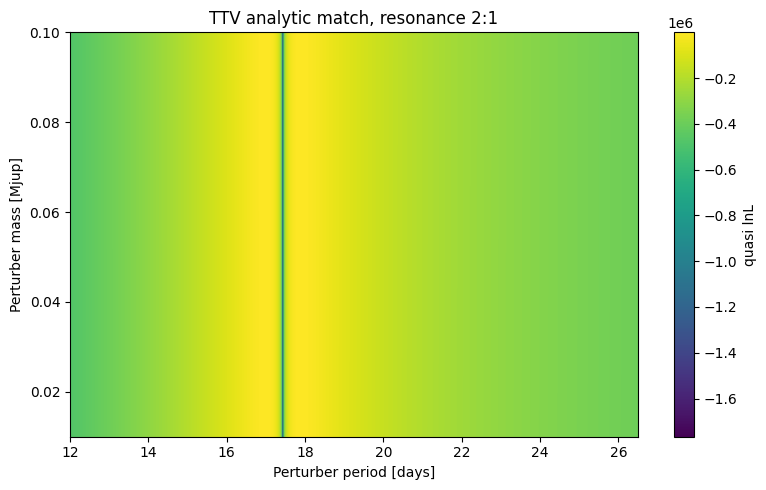

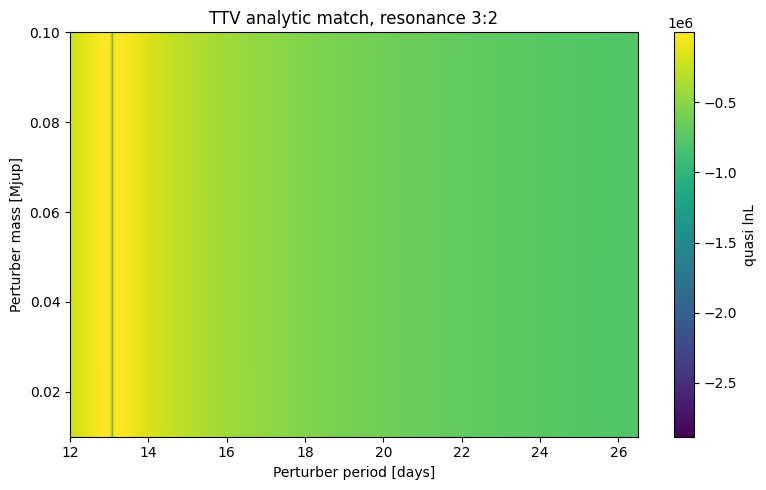

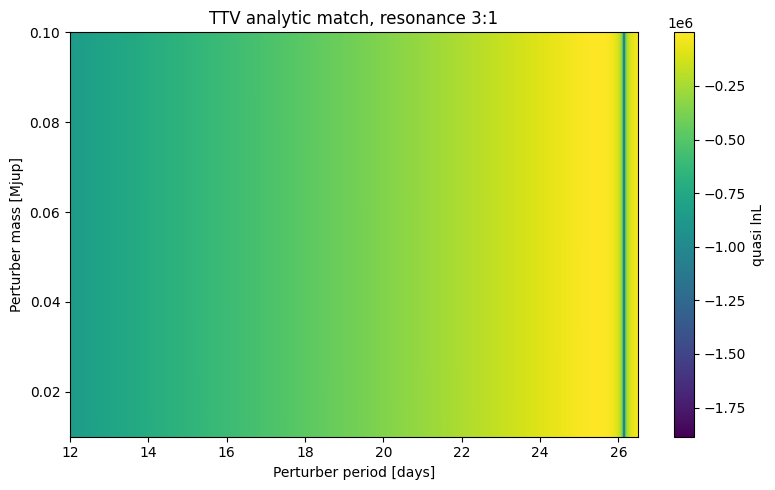

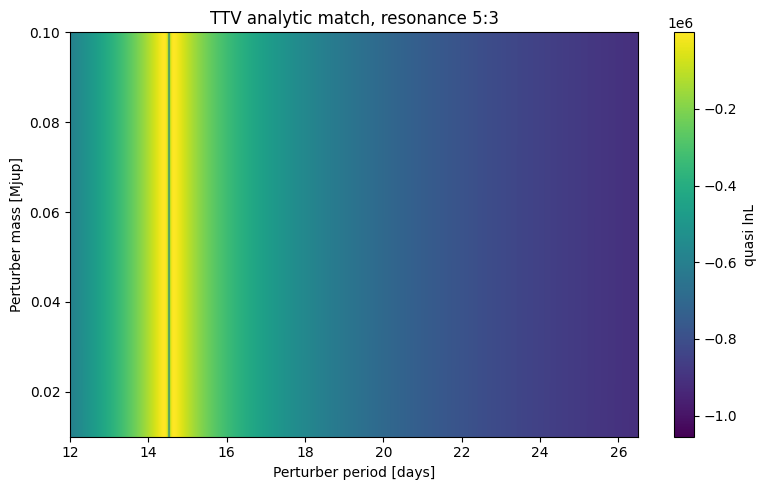

In [18]:
plot_lnl_map(res, resonance='2:1')
plot_lnl_map(res, resonance='3:2')
plot_lnl_map(res, resonance='3:1')
plot_lnl_map(res, resonance='5:3')

## Plot amplitude and super-period maps

In [ ]:
plot_amplitude_map(res, resonance='2:1', output_unit='days')
plot_superperiod_map(res, resonance='2:1')

## Save best solutions

In [ ]:
save_best_table(res, filename='analytic_ttv_best_solutions.csv')

## Notes

1. The returned lnL is a quasi-likelihood used for ranking. Do not interpret it as a rigorous Bayesian likelihood.

2. The amplitude formula is only a first-pass scaling. It ignores free eccentricity, resonant angle phase, inclination effects, secular terms, and resonance coefficients.

3. If a strong match is found, the next step should be to run a numerical model and extract synthetic transit times.

4. Near exact resonance the analytic amplitude diverges. This notebook uses delta_floor and an optional Delta penalty to avoid pathological exact-resonance solutions.

5. For a transiting outer planet perturbed by an inner planet, the same super-period expression can be used, but the amplitude scaling should be treated separately.